In [4]:
# COMSCI/ECON 206 PS1
# Ticketing Rules, Speculation, and Genuine Audience Access
# Author: Jiayang Sun

import random
import pandas as pd

print("Notebook setup complete.")

Notebook setup complete.


In [5]:
def simulate_ticket_market(
    ticket_supply=100,
    genuine_demand=140,
    reseller_share=0.20,
    rule="refundable_nontransferable",
    refund_rate=0.80,
    resale_success_rate=0.70,
    seed=206
):
    """
    Simulate a simplified digital ticket market.

    Parameters
    ----------
    ticket_supply : int
        Number of tickets available.

    genuine_demand : int
        Number of genuine audience members who want tickets.

    reseller_share : float
        Share of all potential buyers who are speculative resellers.
        Example: 0.20 means 20% of potential buyers are resellers.

    rule : str
        "refundable_nontransferable"
        or
        "transferable_nonrefundable"

    refund_rate : float
        Under the refundable but non-transferable rule,
        assumed share of reseller-held tickets that are refunded.

    resale_success_rate : float
        Under the transferable but non-refundable rule,
        assumed share of reseller-held tickets successfully transferred
        to genuine consumers.

    seed : int
        Random seed for reproducibility.

    Notes
    -----
    refund_rate and resale_success_rate are synthetic assumptions
    used for illustration. They are not empirical estimates.
    """

    random.seed(seed)

    # Convert reseller share of ALL buyers into a reseller count.
    reseller_count = int(
        genuine_demand * reseller_share / (1 - reseller_share)
    )

    genuine_count = genuine_demand

    buyers = (
        ["genuine"] * genuine_count
        + ["reseller"] * reseller_count
    )

    random.shuffle(buyers)

    # Tickets are allocated randomly among potential buyers.
    initial_winners = buyers[:ticket_supply]

    genuine_initial = initial_winners.count("genuine")
    reseller_initial = initial_winners.count("reseller")

    resale_tickets = 0
    refunded_tickets = 0
    unused_tickets = 0

    if rule == "refundable_nontransferable":

        # Resellers cannot legally transfer their tickets.
        refunded_tickets = int(reseller_initial * refund_rate)
        unused_tickets = reseller_initial - refunded_tickets

        # Refunded tickets return to genuine consumers
        # when unmet genuine demand remains.
        unmet_genuine_demand = max(
            0,
            genuine_count - genuine_initial
        )

        reallocated = min(
            refunded_tickets,
            unmet_genuine_demand
        )

        genuine_final = genuine_initial + reallocated
        reseller_final = reseller_initial - refunded_tickets

    elif rule == "transferable_nonrefundable":

        # Resellers may legally transfer tickets.
        resale_tickets = reseller_initial

        transferred_to_genuine = int(
            resale_tickets * resale_success_rate
        )

        genuine_final = genuine_initial + transferred_to_genuine
        reseller_final = reseller_initial - transferred_to_genuine

    else:
        raise ValueError(
            "rule must be 'refundable_nontransferable' "
            "or 'transferable_nonrefundable'"
        )

    genuine_access_rate = genuine_final / genuine_count

    return {
        "rule": rule,
        "ticket_supply": ticket_supply,
        "genuine_demand": genuine_demand,
        "reseller_share": reseller_share,
        "reseller_count": reseller_count,
        "genuine_initial": genuine_initial,
        "reseller_initial": reseller_initial,
        "genuine_final": genuine_final,
        "reseller_final": reseller_final,
        "resale_tickets": resale_tickets,
        "refunded_tickets": refunded_tickets,
        "unused_tickets": unused_tickets,
        "genuine_access_rate": genuine_access_rate
    }

In [6]:
result_a = simulate_ticket_market(
    rule="refundable_nontransferable"
)

result_b = simulate_ticket_market(
    rule="transferable_nonrefundable"
)

results = pd.DataFrame([result_a, result_b])

results

,rule,ticket_supply,genuine_demand,reseller_share,reseller_count,genuine_initial,reseller_initial,genuine_final,reseller_final,resale_tickets,refunded_tickets,unused_tickets,genuine_access_rate
0,refundable_nontransferable,100,140,0.2,35,77,23,95,5,0,18,5,0.678571
1,transferable_nonrefundable,100,140,0.2,35,77,23,93,7,23,0,0,0.664286


In [7]:
import matplotlib.pyplot as plt

reseller_shares = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

experiment_rows = []

for share in reseller_shares:
    for rule in [
        "refundable_nontransferable",
        "transferable_nonrefundable"
    ]:
        result = simulate_ticket_market(
            ticket_supply=100,
            genuine_demand=140,
            reseller_share=share,
            rule=rule,
            seed=206
        )
        experiment_rows.append(result)

experiment_df = pd.DataFrame(experiment_rows)

summary = experiment_df[
    [
        "rule",
        "reseller_share",
        "reseller_count",
        "genuine_final",
        "resale_tickets",
        "refunded_tickets",
        "unused_tickets",
        "genuine_access_rate"
    ]
]

summary

,rule,reseller_share,reseller_count,genuine_final,resale_tickets,refunded_tickets,unused_tickets,genuine_access_rate
0,refundable_nontransferable,0.0,0,100,0,0,0,0.714286
1,transferable_nonrefundable,0.0,0,100,0,0,0,0.714286
2,refundable_nontransferable,0.1,15,98,0,8,2,0.700000
3,transferable_nonrefundable,0.1,15,97,10,0,0,0.692857
4,refundable_nontransferable,0.2,35,95,0,18,5,0.678571
5,transferable_nonrefundable,0.2,35,93,23,0,0,0.664286
6,refundable_nontransferable,0.3,60,93,0,25,7,0.664286
7,transferable_nonrefundable,0.3,60,90,32,0,0,0.642857
8,refundable_nontransferable,0.4,93,91,0,33,9,0.650000
9,transferable_nonrefundable,0.4,93,87,42,0,0,0.621429


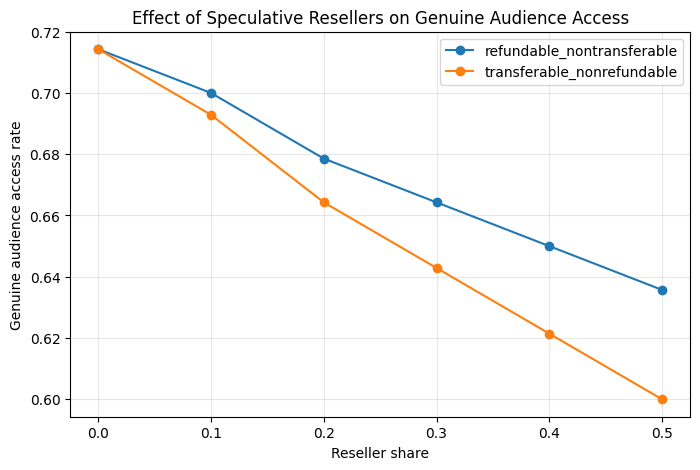

In [8]:
plt.figure(figsize=(8, 5))

for rule in experiment_df["rule"].unique():
    subset = experiment_df[experiment_df["rule"] == rule]

    plt.plot(
        subset["reseller_share"],
        subset["genuine_access_rate"],
        marker="o",
        label=rule
    )

plt.xlabel("Reseller share")
plt.ylabel("Genuine audience access rate")
plt.title("Effect of Speculative Resellers on Genuine Audience Access")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()